1. Import and setup

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, ClassifierMixin
import time
from xrfm import xRFM
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
import torch
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from itertools import product
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
from xgboost import plot_importance
from xrfm.tree_utils import get_param_tree
import seaborn as sns
import torch
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

# Prevent output being printed out
import os
import sys
from contextlib import redirect_stdout

In [31]:
# Columns of the dataset
columns = [
    "Date",
    "WSR0","WSR1","WSR2","WSR3","WSR4","WSR5","WSR6","WSR7","WSR8","WSR9",
    "WSR10","WSR11","WSR12","WSR13","WSR14","WSR15","WSR16","WSR17","WSR18","WSR19",
    "WSR20","WSR21","WSR22","WSR23",
    "WSR_PK","WSR_AV",
    "T0","T1","T2","T3","T4","T5","T6","T7","T8","T9",
    "T10","T11","T12","T13","T14","T15","T16","T17","T18","T19",
    "T20","T21","T22","T23",
    "T_PK","T_AV",
    "T85","RH85","U85","V85","HT85",
    "T70","RH70","U70","V70","HT70",
    "T50","RH50","U50","V50","HT50",
    "KI","TT","SLP","SLP_","Precp",
    "Target"
]

dataset1 = pd.read_csv("ozone+level+detection/eighthr.data", header=None, names=columns)
dataset2 = pd.read_csv("ozone+level+detection/eighthr.data", header=None, names=columns)
dataset = pd.concat([dataset1, dataset2], axis=0)

print(f"Dataset shape: {dataset.shape}")
# Drop the date
dataset = dataset.drop("Date", axis=1)
columns.pop(0)

# Fill "?" value into NaN
dataset.replace(["?"], np.nan, inplace=True)
print(f"Missing values:\n{dataset.isnull().sum()}")
dataset.head()

Dataset shape: (5068, 74)
Missing values:
WSR0      598
WSR1      584
WSR2      588
WSR3      584
WSR4      586
         ... 
TT        250
SLP       190
SLP_      316
Precp       4
Target      0
Length: 73, dtype: int64


,WSR0,WSR1,WSR2,WSR3,WSR4,WSR5,WSR6,WSR7,WSR8,WSR9,...,RH50,U50,V50,HT50,KI,TT,SLP,SLP_,Precp,Target
0,0.8,1.8,2.4,2.1,2,2.1,1.5,1.7,1.9,2.3,...,0.15,10.67,-1.56,5795,-12.1,17.9,10330,-55,0,0.0
1,2.8,3.2,3.3,2.7,3.3,3.2,2.9,2.8,3.1,3.4,...,0.48,8.39,3.84,5805,14.05,29,10275,-55,0,0.0
2,2.9,2.8,2.6,2.1,2.2,2.5,2.5,2.7,2.2,2.5,...,0.6,6.94,9.8,5790,17.9,41.3,10235,-40,0,0.0
3,4.7,3.8,3.7,3.8,2.9,3.1,2.8,2.5,2.4,3.1,...,0.49,8.73,10.54,5775,31.15,51.7,10195,-40,2.08,0.0
4,2.6,2.1,1.6,1.4,0.9,1.5,1.2,1.4,1.3,1.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.58,0.0


In [12]:
# Fill the missing value with the mean of the column
for col in columns:
    dataset[col] = pd.to_numeric(dataset[col])
    dataset[col] = dataset[col].fillna(dataset[col].mean())

print(f"Dataset info:\n{dataset.info()}")
print()
print(f"Missing values after cleaning:\n{dataset.isnull().sum()}")

<class 'pandas.core.frame.DataFrame'>
Index: 5068 entries, 0 to 2533
Data columns (total 73 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   WSR0    5068 non-null   float64
 1   WSR1    5068 non-null   float64
 2   WSR2    5068 non-null   float64
 3   WSR3    5068 non-null   float64
 4   WSR4    5068 non-null   float64
 5   WSR5    5068 non-null   float64
 6   WSR6    5068 non-null   float64
 7   WSR7    5068 non-null   float64
 8   WSR8    5068 non-null   float64
 9   WSR9    5068 non-null   float64
 10  WSR10   5068 non-null   float64
 11  WSR11   5068 non-null   float64
 12  WSR12   5068 non-null   float64
 13  WSR13   5068 non-null   float64
 14  WSR14   5068 non-null   float64
 15  WSR15   5068 non-null   float64
 16  WSR16   5068 non-null   float64
 17  WSR17   5068 non-null   float64
 18  WSR18   5068 non-null   float64
 19  WSR19   5068 non-null   float64
 20  WSR20   5068 non-null   float64
 21  WSR21   5068 non-null   float64
 22  WSR22

In [13]:
SEED = 48
feature_col = columns[: -1]
target_col = "Target"

# Standardize the numerical value
scaler = StandardScaler()
dataset[feature_col] = scaler.fit_transform(dataset[feature_col])
print("Standardize the numerical value")
print("Sample of scaled data")
print(dataset[feature_col].head())

# Splitting of data
# Training = 80%, validation = 10%, test = 10%
X_train, X_val, y_train, y_val = train_test_split(
    dataset[feature_col], dataset[target_col], test_size=0.2, shuffle=True, stratify=dataset[target_col], random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_val, y_val, test_size=0.5, stratify=y_val, random_state=SEED
)

print()
print(f"Training size: {X_train.shape}")
print(f"Validation size: {X_val.shape}")
print(f"Test size: {X_test.shape}")

Standardize the numerical value
Sample of scaled data
       WSR0      WSR1      WSR2      WSR3      WSR4      WSR5      WSR6  \
0 -0.703472  0.179373  0.733142  0.505957  0.423468  0.505817 -0.126209   
1  0.971104  1.354772  1.505395  1.035205  1.576666  1.503695  1.155144   
2  1.054833  1.018944  0.904754  0.505957  0.600883  0.868682  0.789043   
3  2.561951  1.858515  1.848619  2.005493  1.221836  1.412979  1.063618   
4  0.803647  0.431244  0.046695 -0.111499 -0.552314 -0.038480 -0.400785   

       WSR7      WSR8      WSR9  ...       T50      RH50       U50  \
0 -0.317853 -0.573011 -0.476334  ... -1.315377 -0.637188  0.087401   
1  0.689381  0.503003  0.480320  ... -1.051700  0.721899 -0.162446   
2  0.597815 -0.304007 -0.302397  ... -1.420848  1.216113 -0.321340   
3  0.414681 -0.124672  0.219415  ... -1.658157  0.763084 -0.125189   
4 -0.592553 -1.111017 -1.259051  ...  0.000000  0.000000  0.000000   

            V50          HT50            KI        TT       SLP          S

In [14]:
# Create xRFM Wrapper for GridSearchCV

# Create log uniform distribution
def loguniform(low, high, size):
    log_low = np.log10(low)
    log_high = np.log10(high)
    
    sample_log = np.random.uniform(log_low, log_high, size=size)
    
    samples = 10 ** sample_log
    
    return samples

# Generate rfm_params distribution
def generate_rfm_params(size):
    bandwidths = loguniform(1, 200, size)
    bandwidth_modes = ["constant", "adaptive"]
    diagonals = [False, True]
    exponents = np.random.uniform(0.7, 1.4, size=size)  
    regularisations = loguniform(1e-6, 1, size=size)
    
    rfm_params_list = []
    
    for bandwidth, mode, diag, exp, reg in list(product(bandwidths, bandwidth_modes, diagonals, exponents, regularisations)):
        kernel = None
        p = np.random.uniform(0, 1)
        norm_p = None
        if p > 0.2:
            kernel = "lpq_kermac"
            norm_p = np.random.uniform(exp, exp + 0.8 * (2 - exp))
        else:
            kernel = "laplace"
        
        rfm_params_list.append(
            {
                "model": {
                    "kernel": kernel,
                    "bandwidth": bandwidth,
                    "exponent": exp,
                    "norm_p": norm_p,
                    "diag": diag,
                    "bandwidth_mode": mode
                },
                "fit": {
                    "reg": reg,
                    "iters": 1,
                    "early_stop_rfm": True,
                    "M_batch_size": 500,
                    "verbose": True
                }
            }
        )
    return rfm_params_list

class xRFMWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, device, rfm_params=None):
        self.rfm_params = rfm_params
        self.device = device
        self.random_state = 48
        self.model = None
    
    @staticmethod
    def convert_df_to_numpy(X):
        return X.to_numpy().astype(np.float32)
    
    def fit(self, X, y):
        # Convert the shape of y
        X = self.convert_df_to_numpy(X)
        y = self.convert_df_to_numpy(y)
        if len(y.shape) == 1:
            y = y.reshape(-1, 1)
    
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.2, random_state=self.random_state
        )
        self.model = xRFM(
            rfm_params=self.rfm_params,
            random_state=SEED,
            device=self.device,
            tuning_metric="accuracy",
            split_method='top_vector_agop_on_subset',
            min_subset_size=10000
        )
        with open(os.devnull, 'w') as f:
            with redirect_stdout(f):
                self.model.fit(X_train, y_train, X_val, y_val)
        return self
    
    def predict(self, X):
        X = self.convert_df_to_numpy(X)
        return self.model.predict(X)

    def predict_proba(self, X):
        X = self.convert_df_to_numpy(X)
        return self.model.predict_proba(X)

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

best_model = {
    "xRFM": (
        xRFMWrapper(device),
        { "rfm_params": generate_rfm_params(10) }
    ),
    "xGBoost": (
        XGBClassifier(objective="binary:logistic", random_state=SEED, device=str(device)),
        {
            "max_depth": np.arange(2, 15, 1),
            "learning_rate": np.linspace(0.01, 2, 50),
            "n_estimators": [5, 100, 50]
        }
    ),
    "MLP": (
        MLPClassifier(random_state=SEED, early_stopping=True, max_iter=500),
        {
            "hidden_layer_sizes": [(50,), (50, 50), (100,)],
            "activation": ["relu", "tanh"],
            "solver": ["sgd", "adam"],
            "alpha": np.linspace(0.001, 2, 10),
            "batch_size": np.arange(200, 600, 10),
            "learning_rate": ["constant", "adaptive"],
            "learning_rate_init": np.linspace(0.001, 1, 10)
        }
    )
}

In [16]:
result = {}

for name, (model, params) in best_model.items():
    print(f"Tuning and training {name} model")
    cv = StratifiedKFold(n_splits=5)
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        cv=cv,
        n_iter=200,
        scoring="accuracy",
        verbose=True
    )
    search.fit(X_val, y_val)
    
    best_param = search.best_params_
    model = model.set_params(**best_param)
    
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    
    result[name] = (model, end - start, best_param)
    print(f"Finish training {name} model")

Tuning and training xRFM model
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
None


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Using hard routing for tree prediction
None



100%|██████████| 1/1 [00:00<00:00, 10.81it/s], ?it/s]

Using hard routing for tree prediction
None


...

Using hard routing for tree prediction
None
Using hard routing for tree prediction
None
Using hard routing for tree prediction
None


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

None


Building trees:   0%|          | 0/1 [00:36<?, ?it/s]


Finish training xRFM model
Tuning and training xGBoost model
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Finish training xGBoost model
Tuning and training MLP model
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Finish training MLP model


In [17]:
# Display the accuracy, auc, training, inference time
statistic = {
    "Models": [],
    "Accuracy": [],
    "ROC-AUC": [],
    "Training Time": [],
    "Inference Time": [],
}
for name, (model, training_t, best_param) in result.items():
    print(f"Best param of {name} model")
    print(f"{best_param}")
    print()
    
    start = time.time()
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    end = time.time()
    fpr, tpr, threshold = roc_curve(y_test, y_pred_proba)
    auc_score = auc(fpr, tpr)
    
    statistic["Models"].append(name)
    statistic["Accuracy"].append(accuracy_score(y_test, y_pred))
    statistic["Inference Time"].append(end - start)
    statistic["Training Time"].append(training_t)
    statistic["ROC-AUC"].append(auc_score)
    
result_df = pd.DataFrame(statistic)
print("Saving result table....")
result_df.to_csv("Basic_Statistic_Btw_Models.csv", index=False)
display(result_df)

Best param of xRFM model
{'rfm_params': {'model': {'kernel': 'lpq_kermac', 'bandwidth': np.float64(4.523494753641187), 'exponent': np.float64(1.2123861576308381), 'norm_p': 1.6792287009948745, 'diag': True, 'bandwidth_mode': 'adaptive'}, 'fit': {'reg': np.float64(1.908269488963924e-05), 'iters': 1, 'early_stop_rfm': True, 'M_batch_size': 500, 'verbose': True}}}

Using hard routing for tree prediction
Using hard routing for tree prediction
Best param of xGBoost model
{'n_estimators': 5, 'max_depth': np.int64(2), 'learning_rate': np.float64(0.5785714285714286)}

Best param of MLP model
{'solver': 'sgd', 'learning_rate_init': np.float64(0.667), 'learning_rate': 'adaptive', 'hidden_layer_sizes': (50,), 'batch_size': np.int64(520), 'alpha': np.float64(0.44522222222222224), 'activation': 'tanh'}

Saving result table....


,Models,Accuracy,ROC-AUC,Training Time,Inference Time
0,xRFM,0.988166,0.998158,36.180021,1.418918
1,xGBoost,0.944773,0.921579,0.069151,0.015135
2,MLP,0.940828,0.942632,2.066639,0.013112


Using hard routing for tree prediction


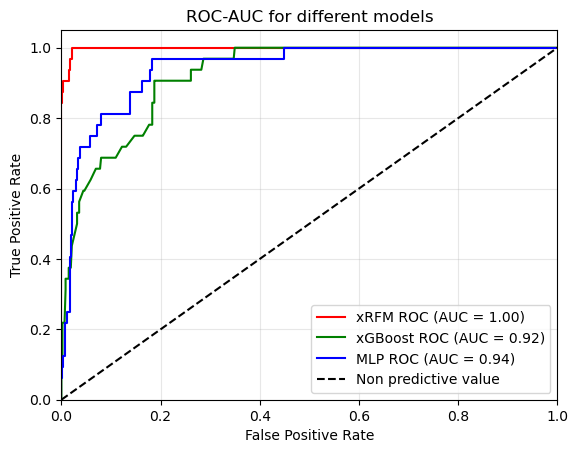

In [18]:
# Display the AUC-ROC graph
xrfm = result["xRFM"][0]
xgb = result["xGBoost"][0]
mlp = result["MLP"][0]
def plot_roc_graph(model, label, color, X_test, y_test):
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, threshold = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=label + f" (AUC = {roc_auc:0.2f})", color=color)


plt.figure()
plt.title("ROC-AUC for different models")
plot_roc_graph(xrfm, "xRFM ROC", "red", X_test, y_test)
plot_roc_graph(xgb, "xGBoost ROC", "green", X_test, y_test)
plot_roc_graph(mlp, "MLP ROC", "blue", X_test, y_test)
plt.plot([0, 1], [0, 1], 'k--', label='Non predictive value')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(alpha=0.3)
plt.legend()
plt.savefig('ROC-AUC-plot.png', dpi=150, bbox_inches='tight')

In [ ]:
# Diplay AGOP matrix
def display_matrix(ax, matrix, color, leaf_count):
    if len(matrix.shape) == 1 or matrix.shape[1] == 1:
        matrix = torch.diag(matrix)

    sns.heatmap(
        matrix,
        cmap=color,
        linewidths=0.5,
        ax=ax,
        alpha=0.8,
        linecolor="grey"
    )
    ax.set_title(f"AGOP of xRFM Leaf {leaf_count}")

def get_leaf_matrix(param_tree, agops):
    if param_tree["type"] == "leaf":
        if param_tree["M"] == None:
            return
        agops.append(param_tree["M"])
        return
    
    get_leaf_matrix(param_tree["left"], agops)
    get_leaf_matrix(param_tree["right"], agops)
    
def get_agops(model):
    agops = []
    for t in model.trees:
        param_tree = get_param_tree(t, is_root=True)
        get_leaf_matrix(param_tree, agops)
    
    return agops

xrfm_model = xrfm.model
print(xrfm_model.trees[0]["model"])
agops = get_agops(xrfm_model)
num_leaf = len(agops)

if len(agops) != 0:    
    fig, axes = plt.subplots(1, num_leaf, figsize=(7 * num_leaf + 5, 7))
    for i in range(num_leaf):
        display_matrix(axes[i], agops[i], "Reds", i)

    plt.savefig('Ozone_level_detection_AGOP.png', dpi=150, bbox_inches='tight')
    plt.tight_layout()
    plt.show()


None


In [ ]:
print(xrfm_model.trees[0]["model"])

None


In [20]:
# PCA Loadings
# Fit PCA
print("Evaluate PCA loadings...\n")
pca = PCA()
pca.fit(X_test)

# Calculate loading
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings_df = pd.DataFrame(
    loadings, index=X_test.columns, columns=[f"PC{i + 1}" for i in range(len(X_test.columns))]
)

# Mutual Information Scores
print("Evaluate mutual information score...\n")
mi_scores = mutual_info_classif(X_test, y_test, random_state=48)
mi_series = pd.Series(mi_scores, index=X_test.columns, name="MI score")

# Permutation importance
print("Evaluate permutation important.....\n")
def get_permutation_importance(model, name, X, y):
    scorer = None
    if name == "xRFM":
        def xrfm_scorer(estimator, X_inp, y_inp):
            y_pred = estimator.predict(X_inp)
            return accuracy_score(y_pred, y_inp)
        
        scorer = xrfm_scorer
    else:
        scorer = "accuracy"
      
    with open(os.devnull, 'w') as f:
        with redirect_stdout(f):  
            result = permutation_importance(
                model, X, y, scoring=scorer, n_repeats=5, random_state=SEED, n_jobs=1
            )

    perm_importance = pd.Series(result.importances_mean, index=X_test.columns, name=f"PI_{name}")
    return perm_importance

rfm_important = get_permutation_importance(xrfm, "xRFM", X_test, y_test)
xgb_important = get_permutation_importance(xgb, "XGBoost", X_test, y_test)
mlp_important = get_permutation_importance(mlp, "MLP", X_test, y_test)

# xgb_important, rfm_important, mlp_important
comparision_df = pd.concat([mi_series, loadings_df, xgb_important, rfm_important, mlp_important], axis=1)
display_comparision_df = pd.concat([mi_series, loadings_df["PC1"], xgb_important, rfm_important, mlp_important], axis=1)

display_comparision_df.sort_values(by="MI score", ascending=False)

comparision_df.to_csv("ozone_detection_feature_importance.csv", index=True)

display(display_comparision_df.head(15))

Evaluate PCA loadings...

Evaluate mutual information score...

Evaluate permutation important.....



,MI score,PC1,PI_XGBoost,PI_xRFM,PI_MLP
WSR0,0.012244,-0.387093,0.000000,3.155819e-03,0.001578
WSR1,0.025892,-0.402323,0.001972,3.944773e-04,0.000394
WSR2,0.014733,-0.460590,0.000000,-1.183432e-03,0.000394
WSR3,0.012266,-0.465042,0.000000,-1.577909e-03,0.001183
WSR4,0.018928,-0.478330,0.000000,-2.366864e-03,-0.000394
WSR5,0.022434,-0.509210,0.000000,-1.577909e-03,-0.000789
WSR6,0.024698,-0.476501,0.000000,-2.366864e-03,-0.000394
WSR7,0.010028,-0.271716,0.000000,0.000000e+00,-0.003550
WSR8,0.017147,-0.254016,0.000000,2.220446e-17,0.000000
WSR9,0.014060,-0.374315,0.000000,5.917160e-03,0.001183


In [21]:
display_comparision_df = display_comparision_df.sort_values(by="PC1", ascending=False)
display(display_comparision_df.head(15))

,MI score,PC1,PI_XGBoost,PI_xRFM,PI_MLP
T18,0.068432,0.950825,0.000000,1.183432e-03,0.000000
T_PK,0.063964,0.948165,0.000000,0.000000e+00,0.002761
T_AV,0.027268,0.944980,0.000000,-3.944773e-04,0.000000
T17,0.058663,0.944536,0.001972,3.944773e-04,0.001578
T19,0.052070,0.944476,0.000000,7.889546e-04,0.000000
T12,0.074363,0.943429,0.000000,0.000000e+00,0.001972
T11,0.053387,0.943358,0.000000,4.733728e-03,0.001972
T20,0.043569,0.940970,0.000000,-1.183432e-03,0.000000
T14,0.066377,0.937702,-0.001183,0.000000e+00,0.002367
T10,0.047240,0.936138,0.000000,0.000000e+00,0.000000


<Figure size 640x480 with 0 Axes>

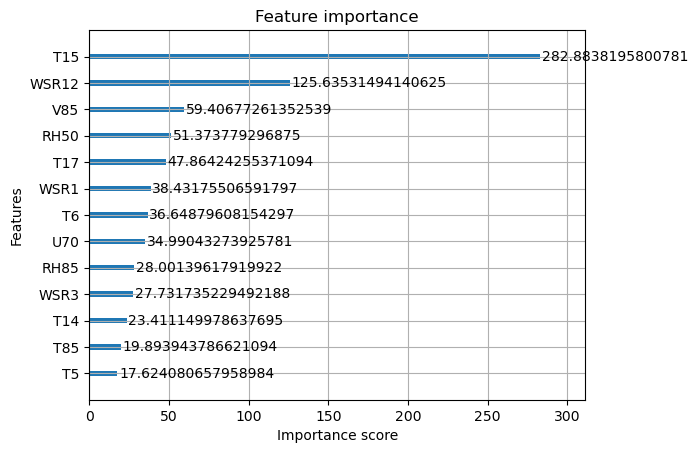

In [22]:
plt.figure()
plot_importance(xgb, importance_type="gain")
plt.savefig('xgb_plot_important.png', dpi=150, bbox_inches='tight')
plt.show()